In [ ]:
# solver for Yukawa potential
# central field potential - use radial schrodinger eqn

In [ ]:
# ========================
# Import Packages/Modules
# ========================
import matplotlib.pyplot as plt           # from hydrogen.py
import numpy as np                        # from hydrogen.py
#import vpython as vp
#vec = vp.vector
from math import *                        # for exponential
#from scipy.constants import e, hbar, m_p  # for numerical values of q_e, hbar, m_p
from jwanglibs import rootfinder as rtf   # from hydrogen.py

In [2]:
#For now, we will be using 1.0 for our constants for easy calculation and visualization.

In [ ]:
# =================
# Define Potential
# =================
def V_eff(r, L):                                                  # effective potential
    '''
    from hydrogen.py
    return L*(L+1)/(2*m*r**2) - 1/(4*pi*)/r                    # centrifugal + coulomb
    '''
    return hbar**2*L*(L+1)/(2*m*r**2) - V0*np.exp(-lamda*r)/r  # centrifugal + yukawa

In [ ]:
# ========================
# Define Numerov Schr Eqn
# ========================
def f(r, L):                            # Sch eqn in Numerov form
    return 2*m*(E-V_eff(r, L))/hbar**2  #rearrange radial Sch eqn

In [ ]:
# ====================
# Define Numerov func
# ====================
def numerov(f, u, n, x, h):     # Numerov integrator for $u''+f(x)u=0$
    nodes, c = 0, h**2/12.       # given $[u_0,u_1]$, return $[u_0,u_1,...,u_{n+1}]$
    f0, f1 = 0., f(x+h)
    for i in range(n):
        x += h
        f2 = f(x+h)             # Numerov method below, 
        u.append((2*(1-5*c*f1)*u[i+1] - (1+c*f0)*u[i])/(1+c*f2))
        f0, f1 = f1, f2
        if u[-1]*u[-2] < 0.0:
            nodes += 1
    return u, nodes             # return u, nodes

In [ ]:
# ==================
# Define shoot func
# ==================
def shoot(En):
    global E                    # E needed in f(r)
    E, c, xm = En, (h**2)/6., xL + M*h
    wfup, nup = numerov(f, [0,.1], M, xL, h)
    wfdn, ndn = numerov(f, [0,.1], N-M, xR, -h)     # $f'$ from 
    dup = ((1+c*f(xm+h))*wfup[-1] - (1+c*f(xm-h))*wfup[-3])/(h+h)
    ddn = ((1+c*f(xm+h))*wfdn[-3] - (1+c*f(xm-h))*wfdn[-1])/(h+h)
    return dup*wfdn[-2] - wfup[-2]*ddn

In [ ]:
# ===================
# Initial Conditions
# ===================
xL, xR, N = 10**(-6), 15., 2200  # limits, interval
m, hbar, V0 =  1.0, 1.0, 1.0     # constants
lamda = 1.0                      # yukawa interaction range
h = (xR-xL)/N                    # step size
Lmax, EL = 4, []                 # define max L, blank L array
M = N // 2                       # M = matching point

In [ ]:
# ================================================
# Calculate energy for n, l, and associated nodes
# ================================================
Estart, dE = -.5/np.arange(1, Lmax+1)**2-.1, 0.001      # $\sum_n -1/2n^2$
for L in range(Lmax):
    n, E1, Ea = L+1, Estart[L], []
    while (E1 < -4*dE):             # sweep E range for each L
        E1 += dE
        if (shoot(E1)*shoot(E1 + dE) > 0):
            continue
        E = rtf.bisect(shoot, E1, E1 + dE, 1.e-8)
        Ea.append(E)
        wfup, nup = numerov(f, [0,.1], M-1, xL, h)      # calc wf
        wfdn, ndn = numerov(f, [0,.1], N-M-1, xR, -h)
        psix = np.concatenate((wfup[:-1], wfdn[::-1]))
        psix[M:] *= wfup[-1]/wfdn[-1]                   # match
        print ('nodes = %i, n = %i,l = %i, E = %.8e' %(nup+ndn, n, L, E))
        n += 1
    EL.append(Ea)

nodes = 0, n = 1,l = 0, E = -9.45212854e-03


<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_5799/2603262054.py:5: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$'), plt.ylabel('$E$')


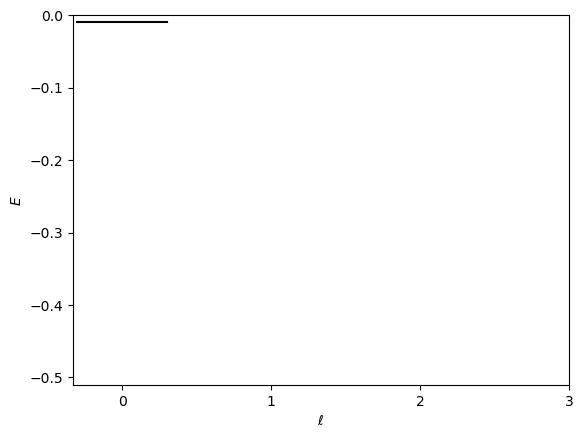

In [ ]:
# =========
# Plotting
# =========
plt.figure()                        # plot energy levels
for L in range(Lmax):
    for i in range(len(EL[L])):
        plt.plot([L-.3, L+.3], [EL[L][i]]*2, 'k-')
    plt.xlabel('$\ell$'), plt.ylabel('$E$')
    plt.ylim(-.51, 0), plt.xticks(range(Lmax))
plt.show()